In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Users/MALLIKARJUN/Downloads/Sample - Superstore.csv~1/Sample - Superstore.csv', encoding='latin1')
print(df.shape)

(9994, 21)


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


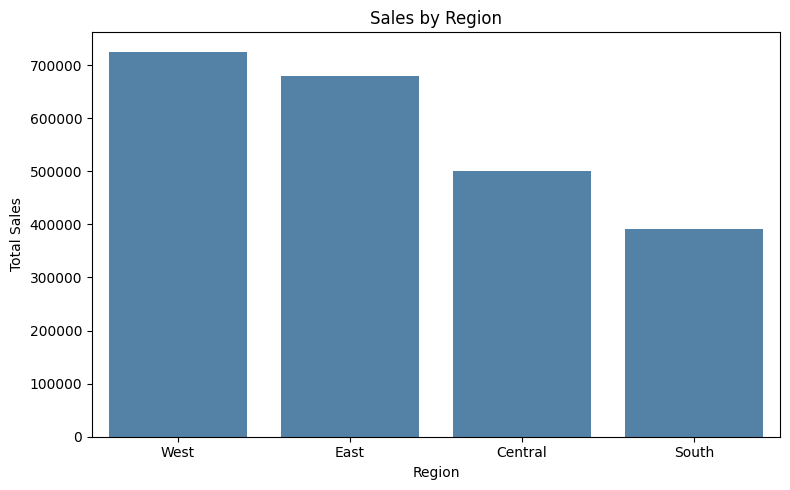

In [10]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=region_sales, color='steelblue')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

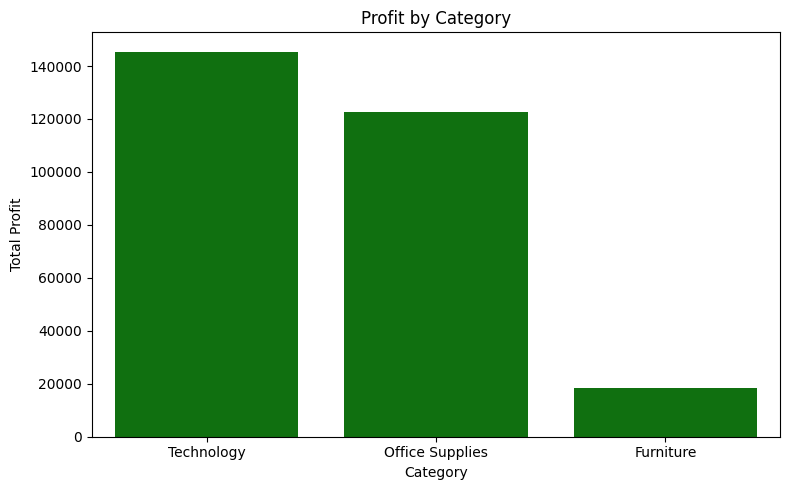

In [11]:
# Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().reset_index()
category_profit = category_profit.sort_values('Profit', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=category_profit, color='green')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

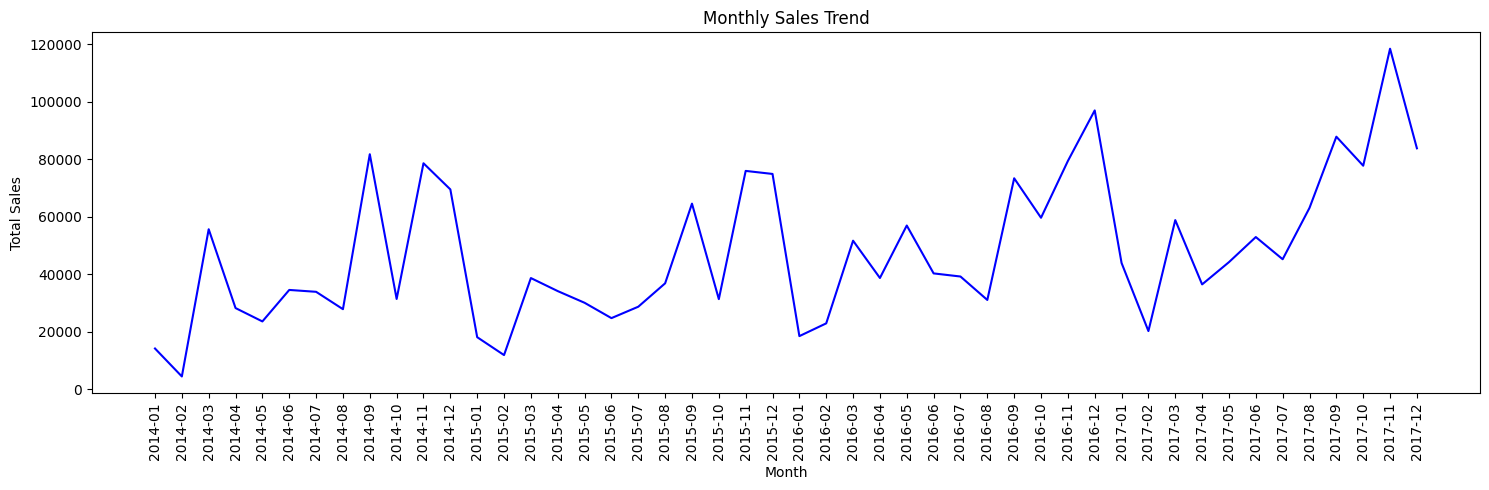

In [12]:
# Monthly Sales Trend
df['Order_Date'] = pd.to_datetime(df['Order Date'])
df['Month_Year'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

plt.figure(figsize=(15,5))
sns.lineplot(x='Month_Year', y='Sales', data=monthly_sales, color='blue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

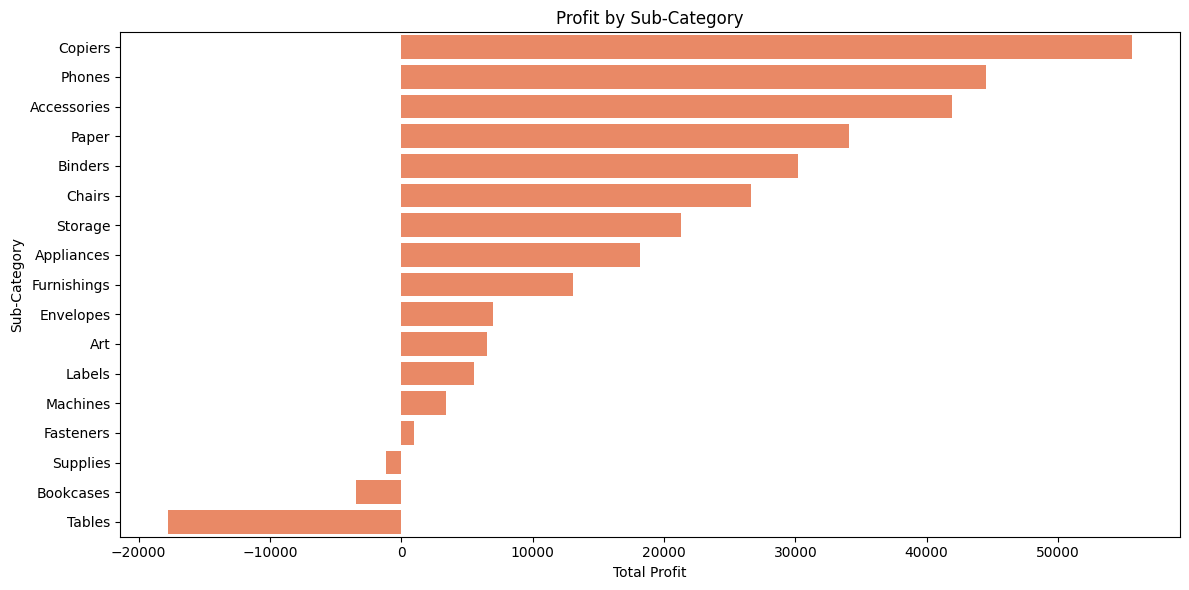

In [13]:
# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
sub_profit = sub_profit.sort_values('Profit', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Profit', y='Sub-Category', data=sub_profit, color='coral')
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

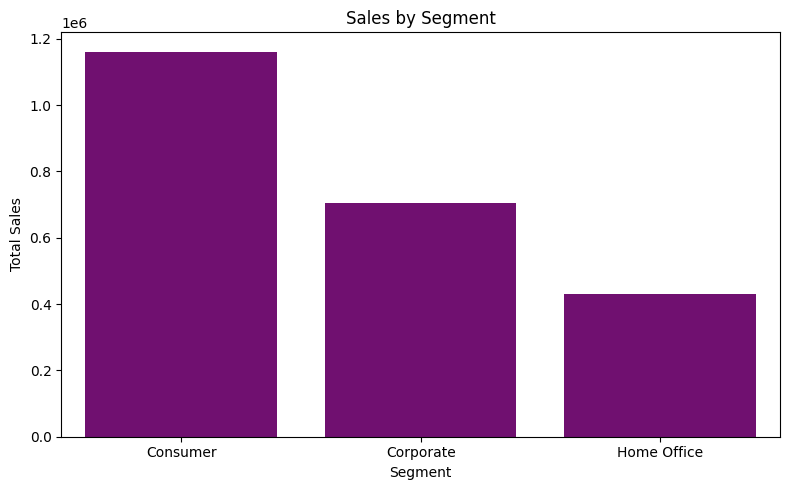

In [14]:
# Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
segment_sales = segment_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Sales', data=segment_sales, color='purple')
plt.title('Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

C:\Users\MALLIKARJUN\AppData\Local\Temp\ipykernel_53864\1374379829.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('Discount_Level')['Profit'].mean().reset_index()


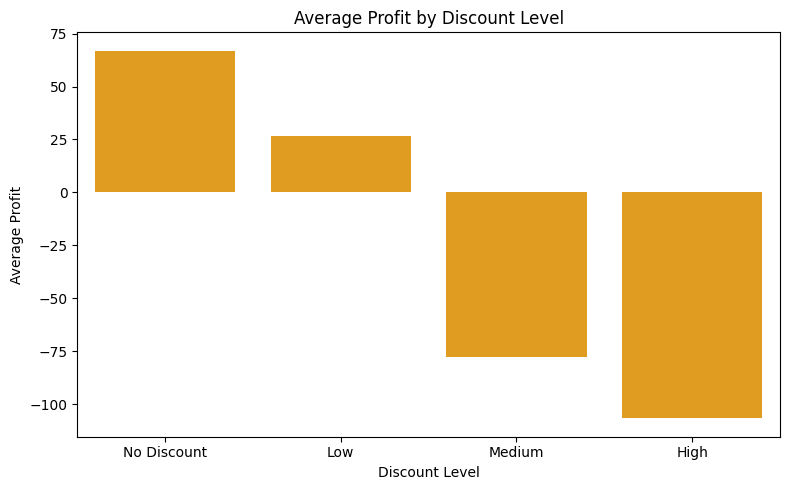

In [16]:
# Discount vs Profit
df['Discount_Level'] = pd.cut(df['Discount'], 
                               bins=[-1, 0, 0.2, 0.4, 1], 
                               labels=['No Discount', 'Low', 'Medium', 'High'])

discount_profit = df.groupby('Discount_Level')['Profit'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Discount_Level', y='Profit', data=discount_profit, color='orange')
plt.title('Average Profit by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.show()